In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

!pip uninstall -y torchao torchaudio diffusers -q
!pip install -U bitsandbytes -q
!pip install git+https://github.com/huggingface/diffusers.git -q
!pip install -U transformers accelerate -q

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch, gc, requests
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login
from diffusers import (
    QwenImage21Transformer2DModel, AutoencoderKLQwenImage21,
    QwenImage21Pipeline, FlowMatchEulerDiscreteScheduler,
    BitsAndBytesConfig as DiffusersBnBConfig,
)
from transformers import (
    Qwen3VLForConditionalGeneration, Qwen3VLProcessor,
    BitsAndBytesConfig as TransformersBnBConfig,
)

user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
login(token=HF_TOKEN)

MODEL_ID = "Qwen/Qwen-Image-2.1"

# تحميل الأجزاء الثلاثة الثقيلة، مكمّمة 4-bit
transformer = QwenImage21Transformer2DModel.from_pretrained(
    MODEL_ID, subfolder="transformer",
    quantization_config=DiffusersBnBConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16),
    dtype=torch.float16,
)
text_encoder = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID, subfolder="text_encoder",
    quantization_config=TransformersBnBConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16),
    dtype=torch.float16, low_cpu_mem_usage=True,
)
vae = AutoencoderKLQwenImage21.from_pretrained(MODEL_ID, subfolder="vae", dtype=torch.float16).to("cuda")
vae.enable_tiling()
vae.enable_slicing()

scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")
processor = Qwen3VLProcessor.from_pretrained(MODEL_ID, subfolder="processor")

pipe = QwenImage21Pipeline(scheduler=scheduler, vae=vae, text_encoder=text_encoder, processor=processor, transformer=transformer)
pipe.enable_attention_slicing("max")

print("✅ الموديل جاهز بالكامل")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

✅ الموديل جاهز بالكامل


In [2]:
def brief_to_image_prompt(b):
    return f"{b['logo_direction']}, professional corporate branding, flat vector design, Adobe Illustrator style, geometric, minimalist icon, clean background, no text, no cartoon, no mascot"

negative_prompt = "text, letters, words, watermark, signature, realistic photo, 3d render, gradient, shadow, complex background, cartoon, mascot, cluttered, blurry, noisy"

briefs = requests.get("https://raw.githubusercontent.com/maram-elaian/brandora/main/data/test_briefs.json").json()[:5]

for brief in briefs:
    with torch.inference_mode():
        image = pipe(
            prompt=brief_to_image_prompt(brief),
            negative_prompt=negative_prompt,
            true_cfg_scale=4.0, width=768, height=768,
            num_inference_steps=30,
            generator=torch.Generator("cuda").manual_seed(42),
        ).images[0]
    image.save(f"QWEN_{brief['id']}.png")
    print(f"✅ {brief['id']}")
    del image
    gc.collect()
    torch.cuda.empty_cache()

  0%|          | 0/30 [00:00<?, ?it/s]

✅ BR001


  0%|          | 0/30 [00:00<?, ?it/s]

✅ BR002


  0%|          | 0/30 [00:00<?, ?it/s]

✅ BR003


  0%|          | 0/30 [00:00<?, ?it/s]

✅ BR004


  0%|          | 0/30 [00:00<?, ?it/s]

✅ BR005


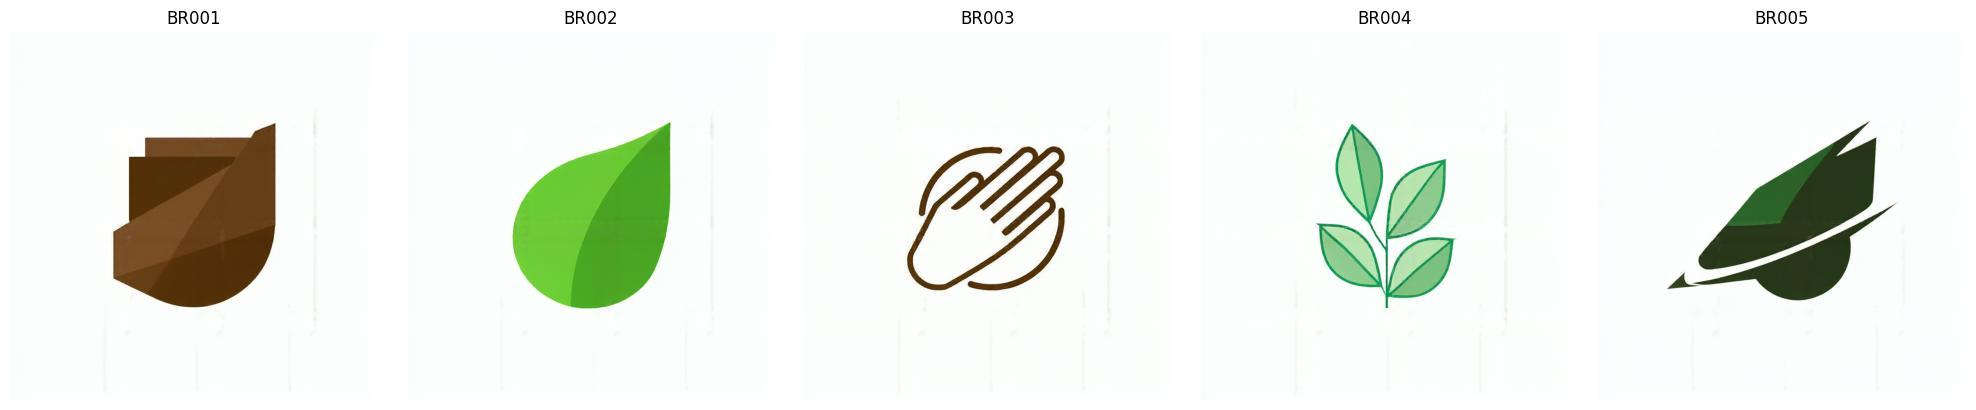

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, brief in zip(axes, briefs):
    img = Image.open(f"QWEN_{brief['id']}.png")
    ax.imshow(img)
    ax.set_title(brief['id'])
    ax.axis('off')

plt.tight_layout()
plt.show()